**1.Load Data and Setup**

In [21]:
"""
Part 1: Data Loading and Configuration
Load both original and aligned profiles with metadata
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt


# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\JSY052_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\figures_layer_averages"

DPI = 150


# ============================================================================
# DATA LOADING
# ============================================================================

def load_profiles_and_metadata(filepath):
    """
    Load both original z-scored and landmark-aligned profiles with metadata.
    
    Returns:
    --------
    data : dict
        Contains:
        - profiles_original: (n_cells, n_bins) original z-scored profiles
        - profiles_aligned: (n_cells, n_bins) landmark-aligned profiles
        - bin_centers: (n_bins,) spatial bin centers in cm
        - landmark_positions: (4,) landmark positions in cm
        - session_labels: (n_cells,) session label per cell
        - layer_labels: (n_cells,) layer label per cell
        - animal_id: str
        - n_sessions: int
        - n_cells: int
    """
    print(f"Loading data from: {filepath}")
    
    data = {}
    
    with h5py.File(filepath, 'r') as f:
        # Metadata
        data['animal_id'] = f['metadata'].attrs['animal_id']
        data['n_sessions'] = f['metadata'].attrs['n_sessions']
        data['n_cells'] = f['metadata'].attrs['n_cells_total']
        data['bin_centers'] = f['metadata/bin_centers_trimmed'][:]
        data['landmark_positions'] = f['metadata/landmark_positions'][:]
        
        # Cell labels
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        
        # Load ORIGINAL z-scored profiles
        if 'features/spatial_profiles_session_corrected' in f:
            data['profiles_original'] = f['features/spatial_profiles_session_corrected'][:]
            print("  Loaded: Original session-corrected z-scored profiles")
        else:
            data['profiles_original'] = f['features/spatial_profiles_zscore'][:]
            print("  Loaded: Original z-scored profiles")
        
        # Load ALIGNED profiles
        if 'features/spatial_profiles_aligned' in f:
            data['profiles_aligned'] = f['features/spatial_profiles_aligned'][:]
            print("  Loaded: Landmark-aligned profiles")
        else:
            print("  WARNING: No aligned profiles found!")
            print("           Run PCA_LandmarkAlignedAnalysis.py first")
            data['profiles_aligned'] = None
    
    print(f"  Animal: {data['animal_id']}")
    print(f"  Cells: {data['n_cells']}")
    print(f"  Sessions: {data['n_sessions']}")
    print(f"  Spatial bins: {len(data['bin_centers'])}")
    
    return data


if __name__ == "__main__":
    # Test data loading
    data = load_profiles_and_metadata(PCA_DATA_PATH)
    print("\nData loading successful!")
    print(f"Profiles shape: {data['profiles_original'].shape}")
    if data['profiles_aligned'] is not None:
        print(f"Aligned profiles shape: {data['profiles_aligned'].shape}")

Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\PCA\JSY052_pca_data.h5
  Loaded: Original z-scored profiles
  Loaded: Landmark-aligned profiles
  Animal: JSY052
  Cells: 2153
  Sessions: 6
  Spatial bins: 115

Data loading successful!
Profiles shape: (2153, 115)
Aligned profiles shape: (2153, 115)


**2.Calculate layer x session averages**

In [22]:
"""
Part 2: Calculate Layer × Session Averages
Compute mean and SEM for each layer-session combination
"""

import numpy as np


def calculate_layer_session_averages(profiles, session_labels, layer_labels):
    """
    Calculate average spatial profiles for each Layer × Session combination.
    
    Parameters:
    -----------
    profiles : array (n_cells, n_bins)
        Spatial profiles (either original or aligned)
    session_labels : array (n_cells,)
        Session label for each cell
    layer_labels : array (n_cells,)
        Layer label for each cell
    
    Returns:
    --------
    averages : dict
        Nested dict: averages[layer][session] = {
            'mean': array (n_bins,),
            'sem': array (n_bins,),
            'n_cells': int
        }
    unique_sessions : list
        Ordered list of session names
    layer_order : list
        Ordered list of layer names
    """
    # Get unique sessions (sorted by day number)
    unique_sessions = sorted(np.unique(session_labels),
                            key=lambda x: int(x.replace('Day', '')))
    
    # Define layer order
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    
    # Initialize nested dict
    averages = {layer: {} for layer in layer_order}
    
    print("\nCalculating Layer × Session averages...")
    
    # Calculate for each combination
    for layer in layer_order:
        for session in unique_sessions:
            # Get cells in this layer and session
            mask = (layer_labels == layer) & (session_labels == session)
            n_cells = np.sum(mask)
            
            if n_cells > 0:
                # Get profiles for these cells
                profiles_subset = profiles[mask]
                
                # Calculate mean and SEM
                mean_profile = np.mean(profiles_subset, axis=0)
                sem_profile = np.std(profiles_subset, axis=0) / np.sqrt(n_cells)
                
                averages[layer][session] = {
                    'mean': mean_profile,
                    'sem': sem_profile,
                    'n_cells': n_cells
                }
                
                print(f"  {layer} × {session}: n={n_cells} cells")
            else:
                # No cells in this combination
                averages[layer][session] = {
                    'mean': None,
                    'sem': None,
                    'n_cells': 0
                }
                print(f"  {layer} × {session}: n=0 cells (SKIPPED)")
    
    print(f"\nTotal combinations: {len(layer_order)} layers × {len(unique_sessions)} sessions")
    
    return averages, unique_sessions, layer_order


if __name__ == "__main__":
    # Test with dummy data
    n_cells = 100
    n_bins = 115
    
    profiles = np.random.randn(n_cells, n_bins)
    session_labels = np.array(['Day1'] * 50 + ['Day7'] * 50)
    layer_labels = np.array(['L2/3'] * 25 + ['L5'] * 25 + ['L2/3'] * 25 + ['L5'] * 25)
    
    averages, sessions, layers = calculate_layer_session_averages(
        profiles, session_labels, layer_labels
    )
    
    print("\nAveraging function test successful!")
    print(f"Layers: {layers}")
    print(f"Sessions: {sessions}")
    print(f"Example mean shape: {averages['L2/3']['Day1']['mean'].shape}")


Calculating Layer × Session averages...
  L2/3 × Day1: n=25 cells
  L2/3 × Day7: n=25 cells
  L4 × Day1: n=0 cells (SKIPPED)
  L4 × Day7: n=0 cells (SKIPPED)
  L5 × Day1: n=25 cells
  L5 × Day7: n=25 cells
  L6 × Day1: n=0 cells (SKIPPED)
  L6 × Day7: n=0 cells (SKIPPED)

Total combinations: 4 layers × 2 sessions

Averaging function test successful!
Layers: ['L2/3', 'L4', 'L5', 'L6']
Sessions: ['Day1', 'Day7']
Example mean shape: (115,)


**3. Plotting functions**

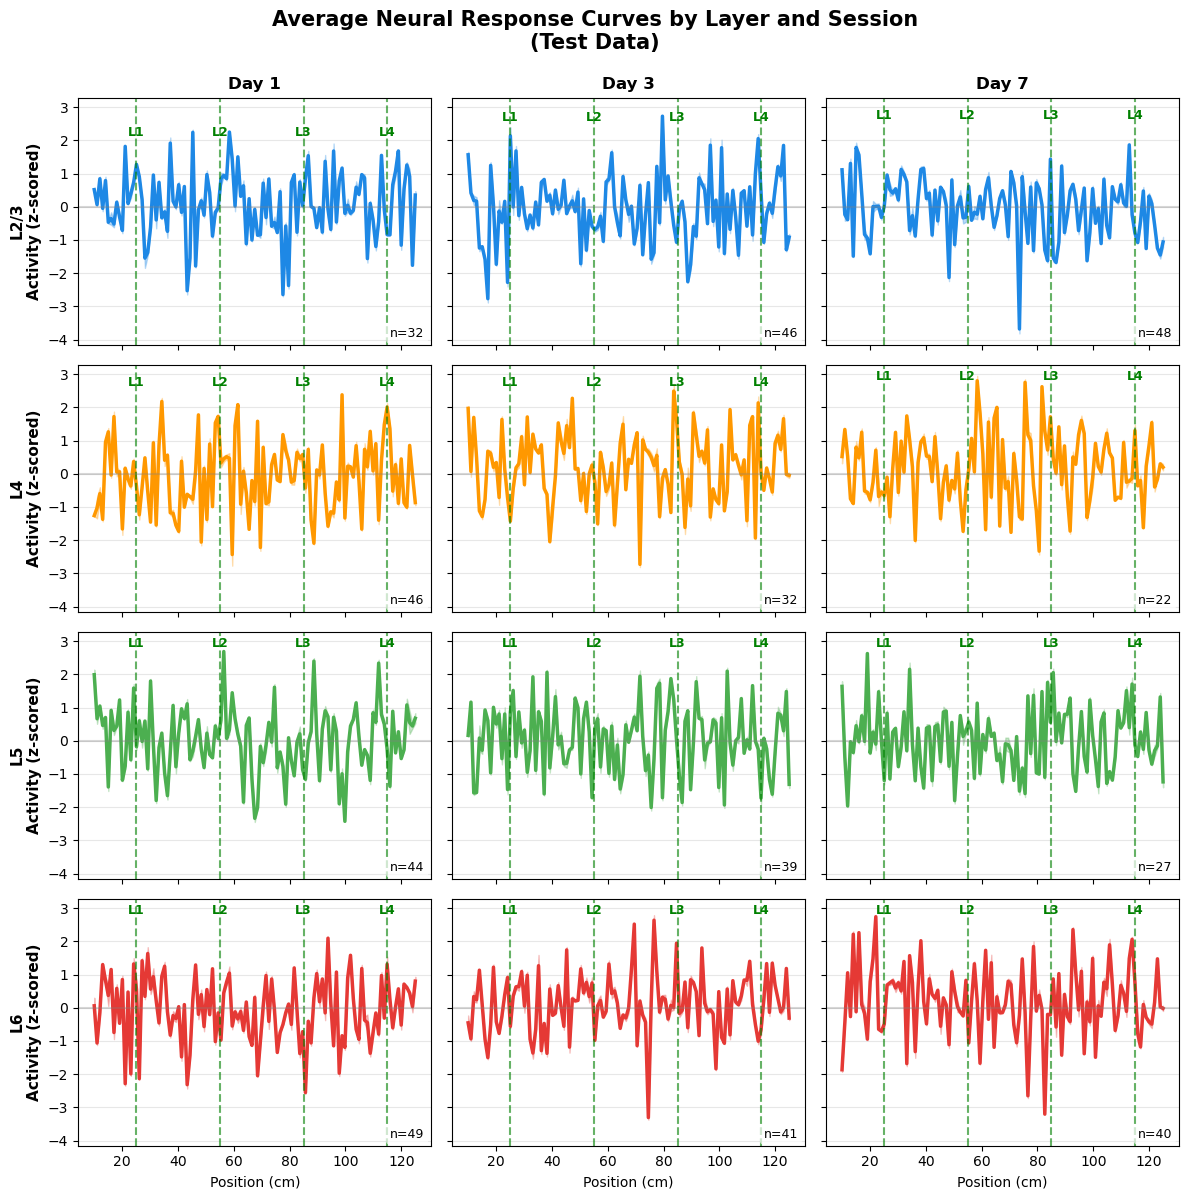


Plotting function test successful!


In [23]:
"""
Part 3: Plotting Function
Create grid visualization of average traces
"""

import numpy as np
import matplotlib.pyplot as plt


def plot_layer_session_average_grid(averages, unique_sessions, layer_order,
                                     bin_centers, landmark_positions,
                                     title_suffix="", save_path=None, dpi=150):
    """
    Plot grid of average spatial profiles: rows=layers, columns=sessions.
    
    Parameters:
    -----------
    averages : dict
        Output from calculate_layer_session_averages()
    unique_sessions : list
        Ordered session names
    layer_order : list
        Ordered layer names
    bin_centers : array
        Spatial bin centers in cm
    landmark_positions : array
        Landmark positions in cm [25, 55, 85, 115]
    title_suffix : str
        Additional text for figure title (e.g., "Original" or "Aligned")
    save_path : str or None
        Path to save figure
    dpi : int
        Figure resolution
    
    Returns:
    --------
    fig : matplotlib figure
    """
    n_layers = len(layer_order)
    n_sessions = len(unique_sessions)
    
    # Create figure
    fig, axes = plt.subplots(n_layers, n_sessions,
                             figsize=(4 * n_sessions, 3 * n_layers),
                             sharex=True, sharey=True)
    
    # Ensure axes is 2D even if only 1 session
    if n_sessions == 1:
        axes = axes.reshape(-1, 1)
    if n_layers == 1:
        axes = axes.reshape(1, -1)
    
    # Layer colors (for consistency with other plots)
    layer_colors = {
        'L2/3': '#1E88E5',  # Blue
        'L4': '#FF9800',    # Orange
        'L5': '#4CAF50',    # Green
        'L6': '#E53935'     # Red
    }
    
    # Plot each Layer × Session panel
    for layer_idx, layer in enumerate(layer_order):
        for session_idx, session in enumerate(unique_sessions):
            ax = axes[layer_idx, session_idx]
            
            # Get data for this combination
            avg_data = averages[layer][session]
            
            if avg_data['mean'] is not None and avg_data['n_cells'] > 0:
                mean = avg_data['mean']
                sem = avg_data['sem']
                n_cells = avg_data['n_cells']
                
                # Plot mean trace
                ax.plot(bin_centers, mean, 
                       color=layer_colors[layer], linewidth=2.5, 
                       label=f'Mean (n={n_cells})')
                
                # Plot SEM shading
                ax.fill_between(bin_centers, mean - sem, mean + sem,
                               color=layer_colors[layer], alpha=0.3)
                
                # Mark all 4 landmarks
                for lm_idx, lm_pos in enumerate(landmark_positions):
                    ax.axvline(lm_pos, color='green', linestyle='--', 
                              alpha=0.6, linewidth=1.5)
                    # Label landmark at top
                    ax.text(lm_pos, ax.get_ylim()[1] * 0.95, f'L{lm_idx+1}',
                           ha='center', va='top', fontsize=9, 
                           color='green', fontweight='bold')
                
                # Add horizontal zero line
                ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
                
            else:
                # No cells in this combination - mark as empty
                ax.text(0.5, 0.5, 'No cells', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=12, color='gray', style='italic')
            
            # Titles and labels
            if layer_idx == 0:
                # Session name at top
                ax.set_title(session.replace('Day', 'Day '), 
                            fontsize=12, fontweight='bold')
            
            if session_idx == 0:
                # Layer name on left
                ax.set_ylabel(f'{layer}\nActivity (z-scored)', 
                             fontsize=11, fontweight='bold')
            
            if layer_idx == n_layers - 1:
                # X-axis label at bottom
                ax.set_xlabel('Position (cm)', fontsize=10)
            
            # Add cell count annotation
            if avg_data['n_cells'] > 0:
                ax.text(0.98, 0.02, f'n={avg_data["n_cells"]}',
                       transform=ax.transAxes, ha='right', va='bottom',
                       fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='white', 
                                alpha=0.7, edgecolor='none'))
            
            # Grid
            ax.grid(alpha=0.3, axis='y')
    
    # Overall title
    plt.suptitle(f'Average Neural Response Curves by Layer and Session\n{title_suffix}',
                fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    
    return fig


if __name__ == "__main__":
    # Test with dummy data
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    unique_sessions = ['Day1', 'Day3', 'Day7']
    bin_centers = np.linspace(10, 125, 115)
    landmark_positions = np.array([25, 55, 85, 115])
    
    # Create dummy averages
    averages = {}
    for layer in layer_order:
        averages[layer] = {}
        for session in unique_sessions:
            # Create synthetic spatial tuning
            mean = np.random.randn(115)
            sem = np.abs(np.random.randn(115) * 0.1)
            averages[layer][session] = {
                'mean': mean,
                'sem': sem,
                'n_cells': np.random.randint(20, 50)
            }
    
    fig = plot_layer_session_average_grid(
        averages, unique_sessions, layer_order,
        bin_centers, landmark_positions,
        title_suffix="(Test Data)"
    )
    
    plt.show()
    print("\nPlotting function test successful!")

**4.Main integration**

In [24]:
"""
LayerSessionAverages_Complete.py
Complete script to visualize average neural response curves by layer and session.

Creates two comprehensive grids:
1. Original z-scored profiles
2. Landmark-aligned profiles

Each grid shows: rows = layers (L2/3, L4, L5, L6)
                 columns = sessions (Day1, Day2, ...)

JSY, 01/2026
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import h5py
import matplotlib.pyplot as plt


# ============================================================================
# FUNCTIONS (integrated from Parts 1-3)
# ============================================================================

def load_profiles_and_metadata(filepath):
    """Load both original and aligned profiles with metadata."""
    print(f"Loading data from: {filepath}")
    
    data = {}
    
    with h5py.File(filepath, 'r') as f:
        # Metadata
        data['animal_id'] = f['metadata'].attrs['animal_id']
        data['n_sessions'] = f['metadata'].attrs['n_sessions']
        data['n_cells'] = f['metadata'].attrs['n_cells_total']
        data['bin_centers'] = f['metadata/bin_centers_trimmed'][:]
        data['landmark_positions'] = f['metadata/landmark_positions'][:]
        
        # Cell labels
        data['session_labels'] = f['cells/session_labels'][:].astype(str)
        data['layer_labels'] = f['cells/layer_labels'][:].astype(str)
        
        # Load ORIGINAL z-scored profiles
        if 'features/spatial_profiles_session_corrected' in f:
            data['profiles_original'] = f['features/spatial_profiles_session_corrected'][:]
            print("  Loaded: Original session-corrected z-scored profiles")
        else:
            data['profiles_original'] = f['features/spatial_profiles_zscore'][:]
            print("  Loaded: Original z-scored profiles")
        
        # Load ALIGNED profiles
        if 'features/spatial_profiles_aligned' in f:
            data['profiles_aligned'] = f['features/spatial_profiles_aligned'][:]
            print("  Loaded: Landmark-aligned profiles")
        else:
            print("  WARNING: No aligned profiles found!")
            print("           Run PCA_LandmarkAlignedAnalysis.py first")
            data['profiles_aligned'] = None
    
    print(f"  Animal: {data['animal_id']}")
    print(f"  Cells: {data['n_cells']}")
    print(f"  Sessions: {data['n_sessions']}")
    print(f"  Spatial bins: {len(data['bin_centers'])}")
    
    return data


def calculate_layer_session_averages(profiles, session_labels, layer_labels):
    """Calculate average spatial profiles for each Layer × Session combination."""
    # Get unique sessions (sorted by day number)
    unique_sessions = sorted(np.unique(session_labels),
                            key=lambda x: int(x.replace('Day', '')))
    
    # Define layer order
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    
    # Initialize nested dict
    averages = {layer: {} for layer in layer_order}
    
    print("\nCalculating Layer × Session averages...")
    
    # Calculate for each combination
    for layer in layer_order:
        for session in unique_sessions:
            # Get cells in this layer and session
            mask = (layer_labels == layer) & (session_labels == session)
            n_cells = np.sum(mask)
            
            if n_cells > 0:
                # Get profiles for these cells
                profiles_subset = profiles[mask]
                
                # Calculate mean and SEM
                mean_profile = np.mean(profiles_subset, axis=0)
                sem_profile = np.std(profiles_subset, axis=0) / np.sqrt(n_cells)
                
                averages[layer][session] = {
                    'mean': mean_profile,
                    'sem': sem_profile,
                    'n_cells': n_cells
                }
                
                print(f"  {layer} × {session}: n={n_cells} cells")
            else:
                # No cells in this combination
                averages[layer][session] = {
                    'mean': None,
                    'sem': None,
                    'n_cells': 0
                }
                print(f"  {layer} × {session}: n=0 cells (SKIPPED)")
    
    print(f"\nTotal combinations: {len(layer_order)} layers × {len(unique_sessions)} sessions")
    
    return averages, unique_sessions, layer_order


def plot_layer_session_average_grid(averages, unique_sessions, layer_order,
                                     bin_centers, landmark_positions,
                                     title_suffix="", save_path=None, dpi=150):
    """Plot grid of average spatial profiles: rows=layers, columns=sessions."""
    n_layers = len(layer_order)
    n_sessions = len(unique_sessions)
    
    # Create figure
    fig, axes = plt.subplots(n_layers, n_sessions,
                             figsize=(4 * n_sessions, 3 * n_layers),
                             sharex=True, sharey=True)
    
    # Ensure axes is 2D even if only 1 session
    if n_sessions == 1:
        axes = axes.reshape(-1, 1)
    if n_layers == 1:
        axes = axes.reshape(1, -1)
    
    # Layer colors
    layer_colors = {
        'L2/3': '#1E88E5',
        'L4': '#FF9800',
        'L5': '#4CAF50',
        'L6': '#E53935'
    }
    
    # Plot each Layer × Session panel
    for layer_idx, layer in enumerate(layer_order):
        for session_idx, session in enumerate(unique_sessions):
            ax = axes[layer_idx, session_idx]
            
            # Get data for this combination
            avg_data = averages[layer][session]
            
            if avg_data['mean'] is not None and avg_data['n_cells'] > 0:
                mean = avg_data['mean']
                sem = avg_data['sem']
                n_cells = avg_data['n_cells']
                
                # Plot mean trace
                ax.plot(bin_centers, mean, 
                       color=layer_colors[layer], linewidth=2.5)
                
                # Plot SEM shading
                ax.fill_between(bin_centers, mean - sem, mean + sem,
                               color=layer_colors[layer], alpha=0.3)
                
                # Mark all 4 landmarks
                for lm_idx, lm_pos in enumerate(landmark_positions):
                    ax.axvline(lm_pos, color='green', linestyle='--', 
                              alpha=0.6, linewidth=1.5)
                    # Label landmark at top
                    ax.text(lm_pos, ax.get_ylim()[1] * 0.95, f'L{lm_idx+1}',
                           ha='center', va='top', fontsize=9, 
                           color='green', fontweight='bold')
                
                # Add horizontal zero line
                ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
                
            else:
                # No cells in this combination
                ax.text(0.5, 0.5, 'No cells', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=12, color='gray', style='italic')
            
            # Titles and labels
            if layer_idx == 0:
                ax.set_title(session.replace('Day', 'Day '), 
                            fontsize=12, fontweight='bold')
            
            if session_idx == 0:
                ax.set_ylabel(f'{layer}\nActivity (z-scored)', 
                             fontsize=11, fontweight='bold')
            
            if layer_idx == n_layers - 1:
                ax.set_xlabel('Position (cm)', fontsize=10)
            
            # Add cell count annotation
            if avg_data['n_cells'] > 0:
                ax.text(0.98, 0.02, f'n={avg_data["n_cells"]}',
                       transform=ax.transAxes, ha='right', va='bottom',
                       fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='white', 
                                alpha=0.7, edgecolor='none'))
            
            # Grid
            ax.grid(alpha=0.3, axis='y')
    
    # Overall title
    plt.suptitle(f'Average Neural Response Curves by Layer and Session\n{title_suffix}',
                fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    
    return fig


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

def run_layer_session_average_analysis(pca_data_path, figure_dir, dpi=150):
    """
    Main function to generate average response curves by layer and session.
    Creates two figures: one for original profiles, one for aligned profiles.
    """
    print("=" * 80)
    print("LAYER × SESSION AVERAGE NEURAL RESPONSE ANALYSIS")
    print("=" * 80)
    
    # Create output directory
    os.makedirs(figure_dir, exist_ok=True)
    
    # Load data
    data = load_profiles_and_metadata(pca_data_path)
    
    # ========================================================================
    # PART 1: ORIGINAL PROFILES
    # ========================================================================
    print("\n" + "=" * 80)
    print("PROCESSING ORIGINAL PROFILES")
    print("=" * 80)
    
    averages_original, sessions, layers = calculate_layer_session_averages(
        data['profiles_original'],
        data['session_labels'],
        data['layer_labels']
    )
    
    print("\nGenerating figure for ORIGINAL profiles...")
    fig_original = plot_layer_session_average_grid(
        averages_original, sessions, layers,
        data['bin_centers'], data['landmark_positions'],
        title_suffix="(Original Z-scored Profiles)",
        save_path=os.path.join(figure_dir, 'layer_session_averages_original.png'),
        dpi=dpi
    )
    
    # ========================================================================
    # PART 2: ALIGNED PROFILES (if available)
    # ========================================================================
    if data['profiles_aligned'] is not None:
        print("\n" + "=" * 80)
        print("PROCESSING LANDMARK-ALIGNED PROFILES")
        print("=" * 80)
        
        averages_aligned, sessions, layers = calculate_layer_session_averages(
            data['profiles_aligned'],
            data['session_labels'],
            data['layer_labels']
        )
        
        print("\nGenerating figure for ALIGNED profiles...")
        fig_aligned = plot_layer_session_average_grid(
            averages_aligned, sessions, layers,
            data['bin_centers'], data['landmark_positions'],
            title_suffix="(Landmark-Aligned Profiles)",
            save_path=os.path.join(figure_dir, 'layer_session_averages_aligned.png'),
            dpi=dpi
        )
    else:
        print("\n" + "=" * 80)
        print("SKIPPING ALIGNED PROFILES (not available)")
        print("Run PCA_LandmarkAlignedAnalysis.py first to generate aligned profiles")
        print("=" * 80)
        fig_aligned = None
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)
    print(f"\nFigures saved to: {figure_dir}")
    print(f"  - layer_session_averages_original.png")
    if fig_aligned is not None:
        print(f"  - layer_session_averages_aligned.png")
    
    print(f"\nAnalyzed:")
    print(f"  {len(layers)} layers × {len(sessions)} sessions = {len(layers) * len(sessions)} combinations")
    print(f"  Total cells: {data['n_cells']}")
    
    # Show figures
    plt.show()
    
    return {
        'averages_original': averages_original,
        'averages_aligned': averages_aligned if data['profiles_aligned'] is not None else None,
        'sessions': sessions,
        'layers': layers,
        'data': data
    }



LAYER × SESSION AVERAGE NEURAL RESPONSE ANALYSIS
Loading data from: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5
  Loaded: Original z-scored profiles
  Loaded: Landmark-aligned profiles
  Animal: JSY054
  Cells: 2864
  Sessions: 7
  Spatial bins: 115

PROCESSING ORIGINAL PROFILES

Calculating Layer × Session averages...
  L2/3 × Day1: n=138 cells
  L2/3 × Day2: n=144 cells
  L2/3 × Day3: n=178 cells
  L2/3 × Day4: n=180 cells
  L2/3 × Day5: n=124 cells
  L2/3 × Day6: n=95 cells
  L2/3 × Day7: n=123 cells
  L4 × Day1: n=138 cells
  L4 × Day2: n=169 cells
  L4 × Day3: n=163 cells
  L4 × Day4: n=165 cells
  L4 × Day5: n=146 cells
  L4 × Day6: n=96 cells
  L4 × Day7: n=108 cells
  L5 × Day1: n=83 cells
  L5 × Day2: n=98 cells
  L5 × Day3: n=102 cells
  L5 × Day4: n=95 cells
  L5 × Day5: n=81 cells
  L5 × Day6: n=83 cells
  L5 × Day7: n=78 cells
  L6 × Day1: n=52 cells
  L6 × Day2: n=41 cells
  L6 × Day3: n=38 cells
  L6 × Day4: n=14 cells
  L6 × Day5: n=

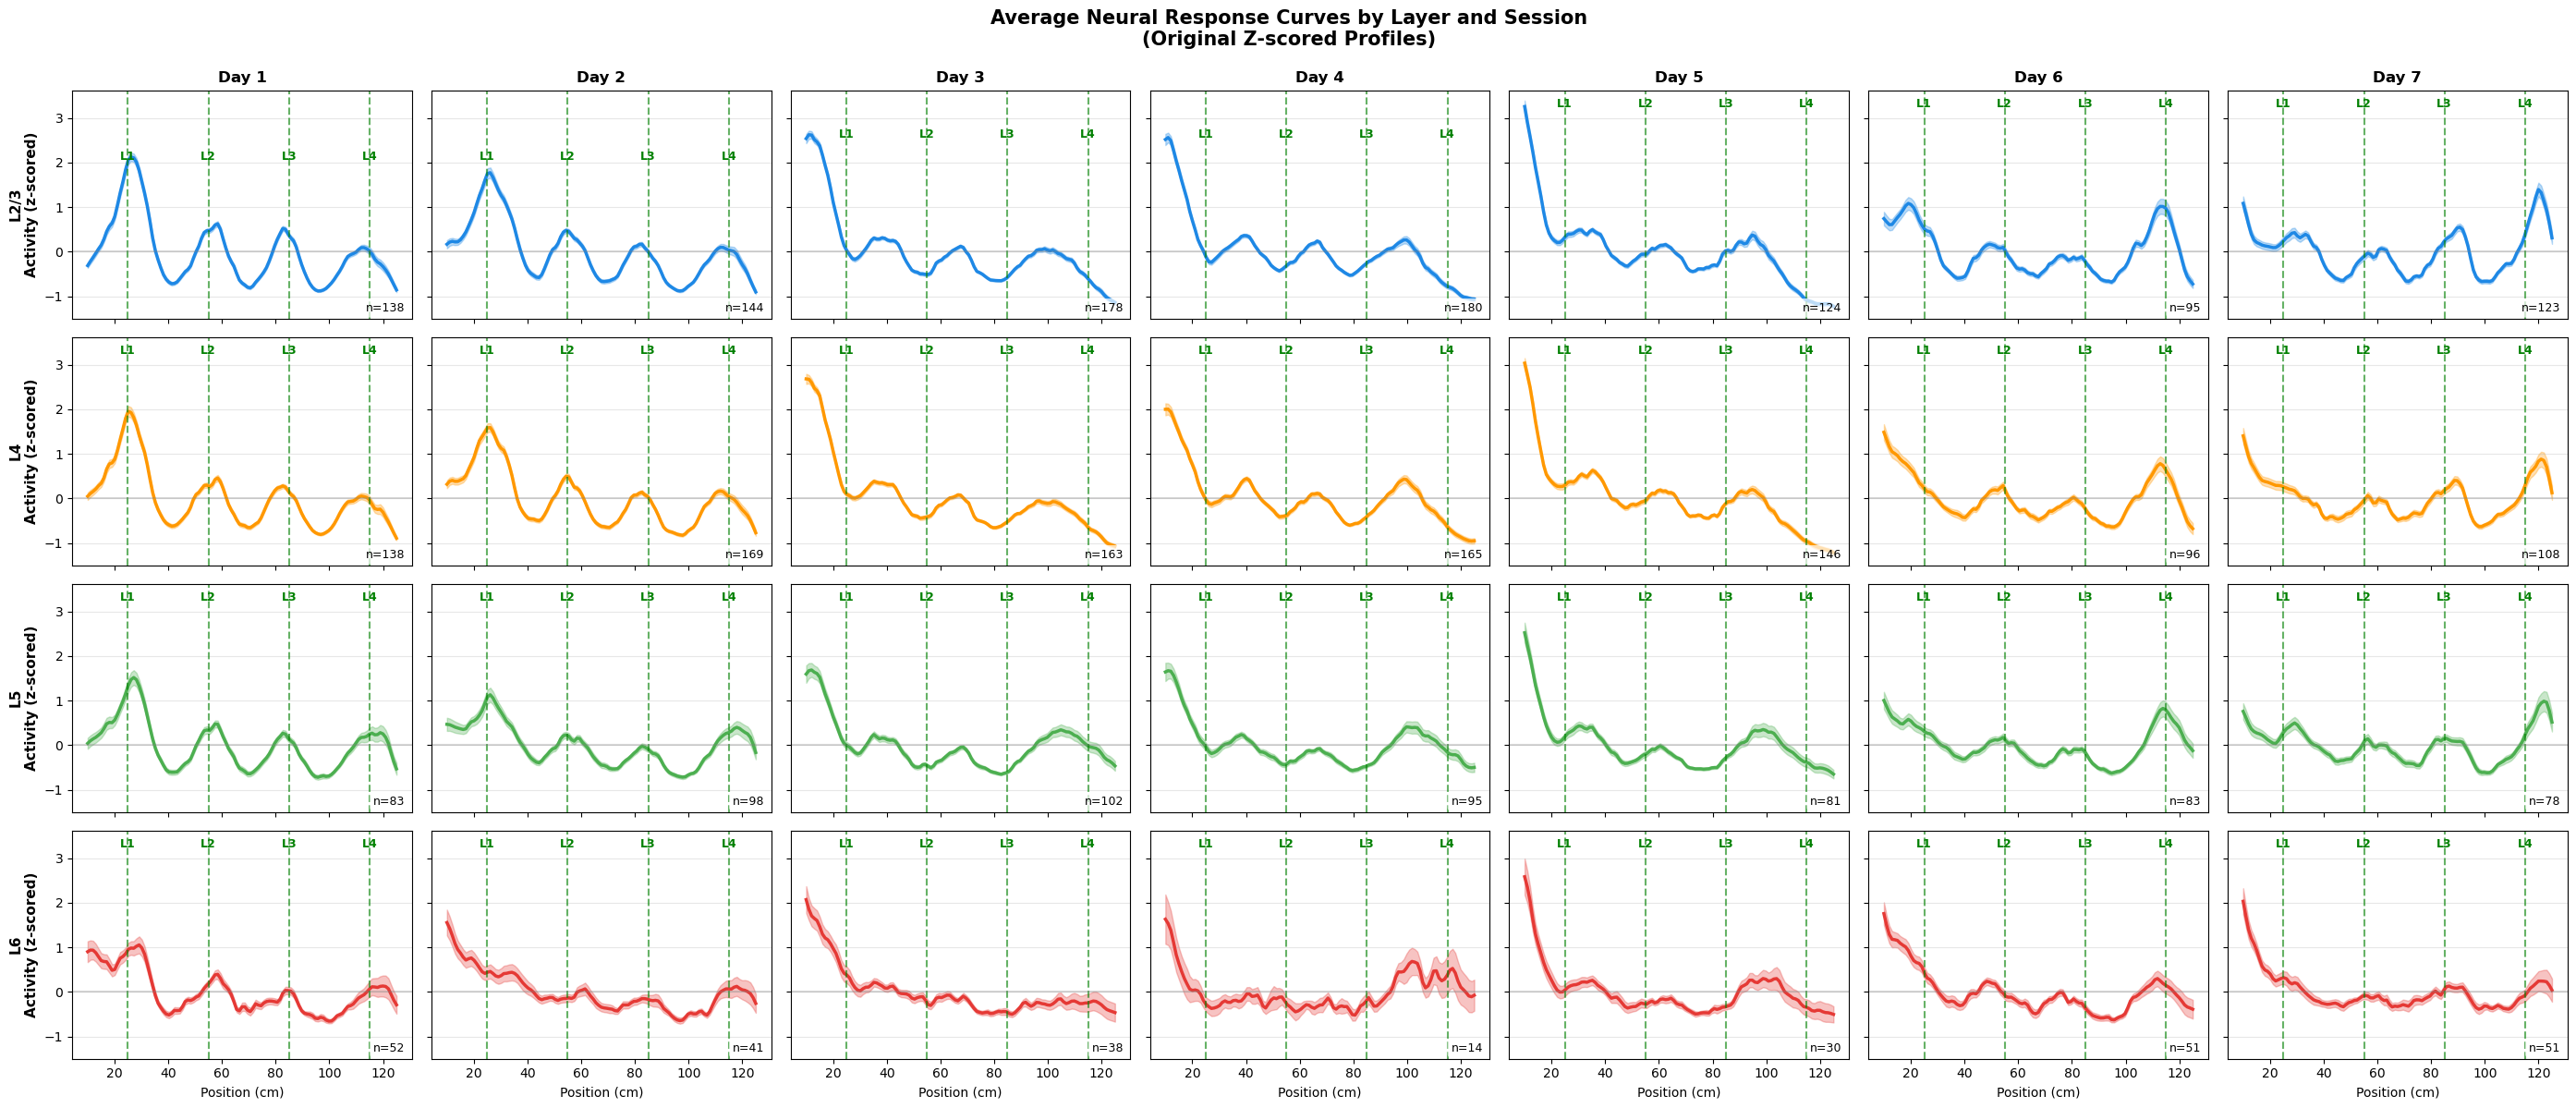

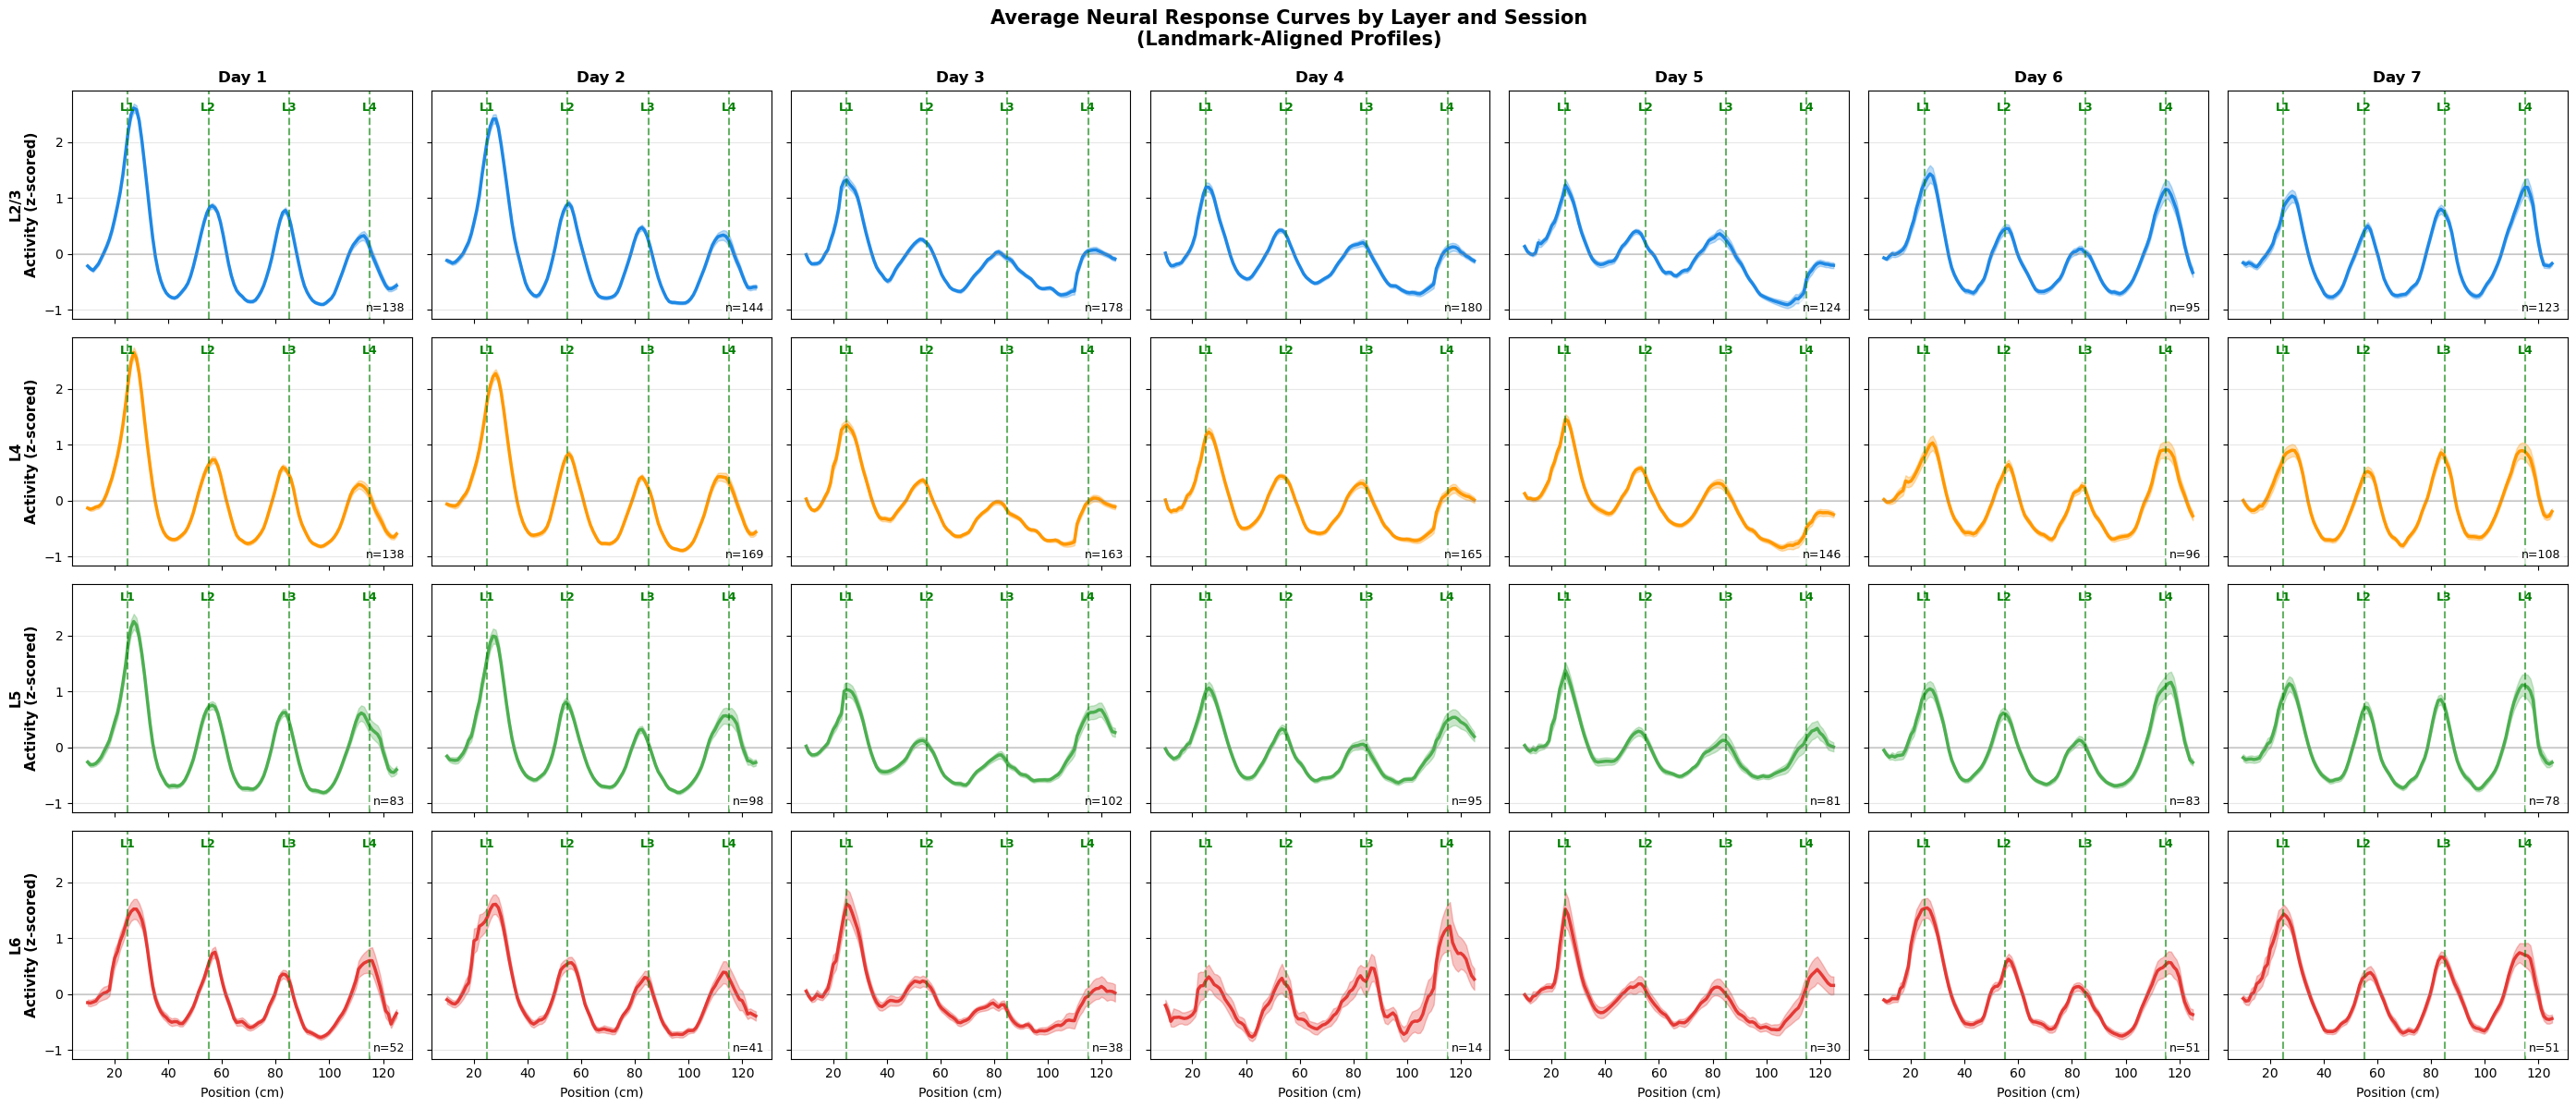

In [25]:
# ============================================================================
# CONFIGURATION
# ============================================================================

PCA_DATA_PATH = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\JSY054_pca_data.h5"
FIGURE_DIR = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\PCA\figures_layer_averages"

DPI = 150

results = run_layer_session_average_analysis(
    pca_data_path=PCA_DATA_PATH,
    figure_dir=FIGURE_DIR,
    dpi=DPI)